In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1: Data Loading & Understanding

In [131]:
df=pd.read_csv("Heart_disease.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [132]:
df.shape

(918, 12)

In [133]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [134]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [135]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [136]:
x=df.drop('HeartDisease', axis=1)
y=df['HeartDisease']

In [137]:
print(y.value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


2: Data Preprocessing

In [139]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [140]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['ExerciseAngina']=le.fit_transform(df['ExerciseAngina'])

In [141]:
df=pd.get_dummies(df,columns=['ChestPainType','RestingECG','ST_Slope'],drop_first=True,dtype=int)

In [143]:
from sklearn.model_selection import train_test_split
x = df.drop('HeartDisease', axis=1)  
y = df['HeartDisease']                
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)


Train shape: (734, 15) (734,)
Test shape: (184, 15) (184,)


In [144]:
from sklearn.preprocessing import  StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

3: Exploratory Data Analysis (EDA) 

In [145]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.396514,198.799564,0.233115,136.809368,0.404139,0.887364,0.553377,0.188453,0.221133,0.050109,0.601307,0.193900,0.501089,0.430283
std,9.432617,0.407701,18.514154,109.384145,0.423046,25.460334,0.490992,1.066570,0.497414,0.391287,0.415236,0.218289,0.489896,0.395567,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,0.000000,0.600000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'Sex'}>,
        <Axes: title={'center': 'RestingBP'}>,
        <Axes: title={'center': 'Cholesterol'}>],
       [<Axes: title={'center': 'FastingBS'}>,
        <Axes: title={'center': 'MaxHR'}>,
        <Axes: title={'center': 'ExerciseAngina'}>,
        <Axes: title={'center': 'Oldpeak'}>],
       [<Axes: title={'center': 'HeartDisease'}>,
        <Axes: title={'center': 'ChestPainType_ATA'}>,
        <Axes: title={'center': 'ChestPainType_NAP'}>,
        <Axes: title={'center': 'ChestPainType_TA'}>],
       [<Axes: title={'center': 'RestingECG_Normal'}>,
        <Axes: title={'center': 'RestingECG_ST'}>,
        <Axes: title={'center': 'ST_Slope_Flat'}>,
        <Axes: title={'center': 'ST_Slope_Up'}>]], dtype=object)

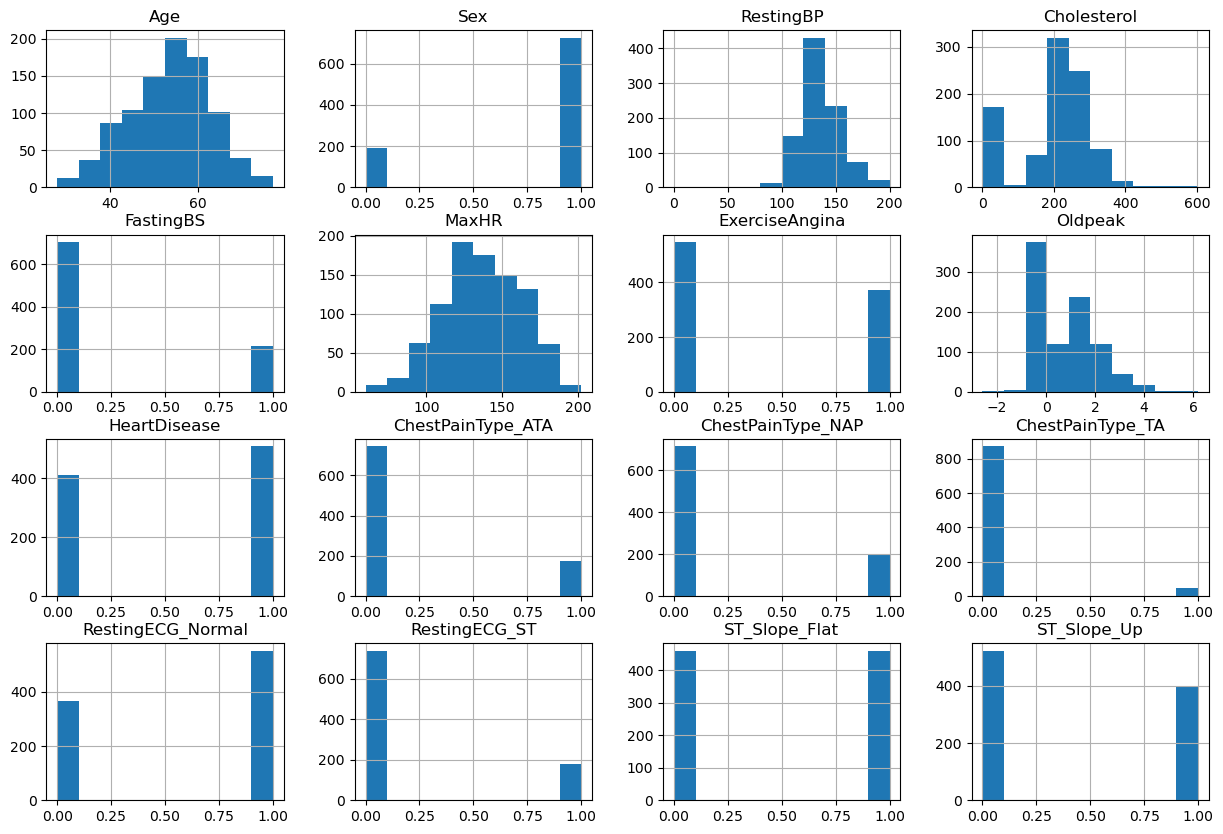

In [146]:
df.hist(figsize=(15,10))

<Axes: >

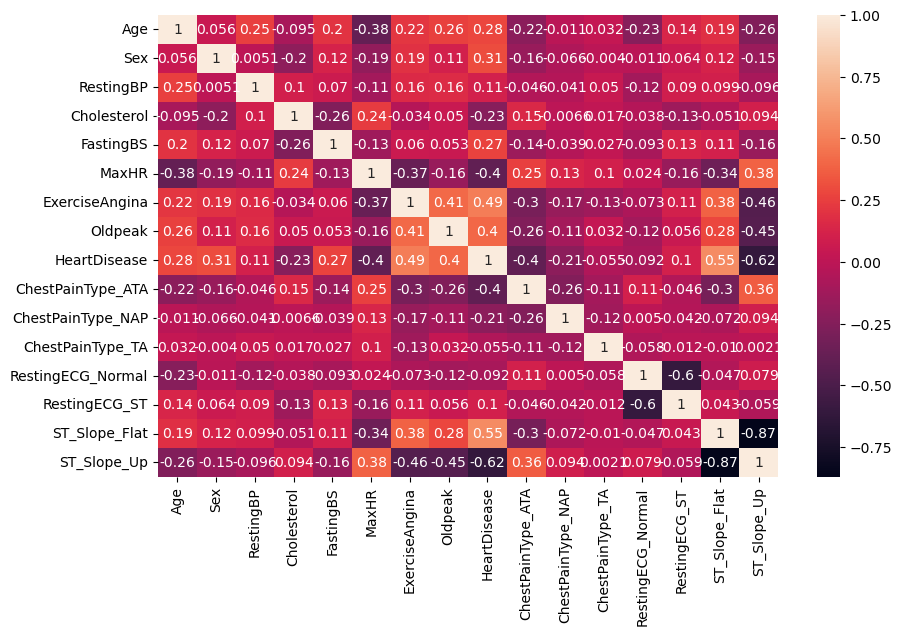

In [153]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

 5: Model Building

In [154]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=10,max_features=3)
model.fit(x_train,y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


6: Model Evaluation

In [157]:
from sklearn.metrics import accuracy_score,classification_report
print('accuracy_score:',accuracy_score(y_test,y_pred))

accuracy_score: 0.8315217391304348


In [158]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82        82
           1       0.87      0.81      0.84       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



7: Prediction on New Data

In [165]:
import warnings
warnings.filterwarnings('ignore')
new_sample = [[37,1,130,283,0,98,0,0.0,1,0,0,0,1,0,1]]
new_sample_scaled = scaler.transform(new_sample)
predicted_label = model.predict(new_sample_scaled)
print("Predicted Label for new sample:", predicted_label)


Predicted Label for new sample: [0]


In [163]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


In [167]:
expected_labels = [0]
comparison = list(zip(expected_labels, predicted_label))
print("Expected vs Predicted:", comparison)


Expected vs Predicted: [(0, np.int64(0))]


8: Hyperparameter Tuning

In [168]:
from sklearn.ensemble import RandomForestClassifier

n_estimators = [10, 50, 100]
max_depth = [3, 5, 10]
min_samples_split = [2, 5, 10]

for n, d, s in zip(n_estimators, max_depth, min_samples_split):
    model = RandomForestClassifier(n_estimators=n, max_depth=d, min_samples_split=s, random_state=42)
    model.fit(x_train, y_train)
    accuracy = model.score(x_test, y_test)

    print("n_estimators =", n,
          "max_depth =", d,
          "min_samples_split =", s,
          "Accuracy =", accuracy)

n_estimators = 10 max_depth = 3 min_samples_split = 2 Accuracy = 0.8097826086956522
n_estimators = 50 max_depth = 5 min_samples_split = 5 Accuracy = 0.8532608695652174
n_estimators = 100 max_depth = 10 min_samples_split = 10 Accuracy = 0.8913043478260869


9: Feature Importance Analysis

In [172]:
import pandas as pd
feature_imp = pd.DataFrame({'Feature': x.columns,'Importance': importance})
print(feature_imp)

              Feature  Importance
0                 Age    0.051721
1                 Sex    0.039802
2           RestingBP    0.045590
3         Cholesterol    0.084294
4           FastingBS    0.028404
5               MaxHR    0.077882
6      ExerciseAngina    0.098512
7             Oldpeak    0.110138
8   ChestPainType_ATA    0.048373
9   ChestPainType_NAP    0.035941
10   ChestPainType_TA    0.010558
11  RestingECG_Normal    0.008919
12      RestingECG_ST    0.005261
13      ST_Slope_Flat    0.148163
14        ST_Slope_Up    0.206443


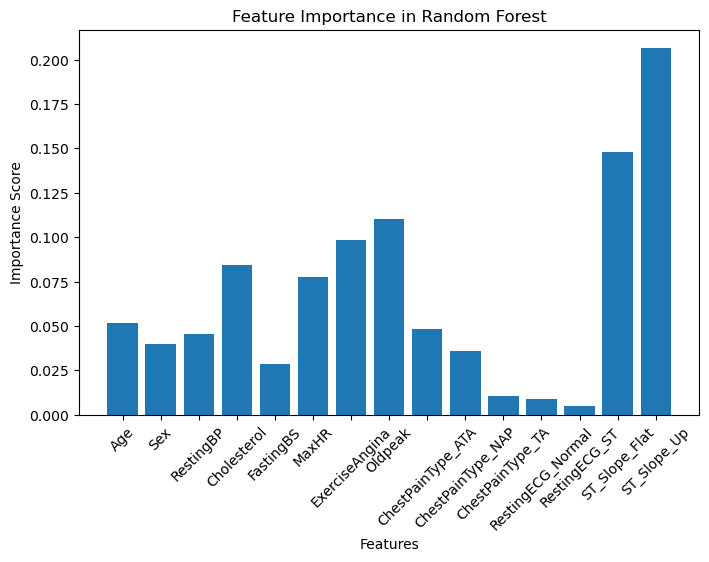

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(feature_imp['Feature'], feature_imp['Importance'])
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Random Forest")
plt.xticks(rotation=45)
plt.show()